In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_auc_score, confusion_matrix

In [2]:
ratios = [round(x * 0.05, 2) for x in range(2, 11)]

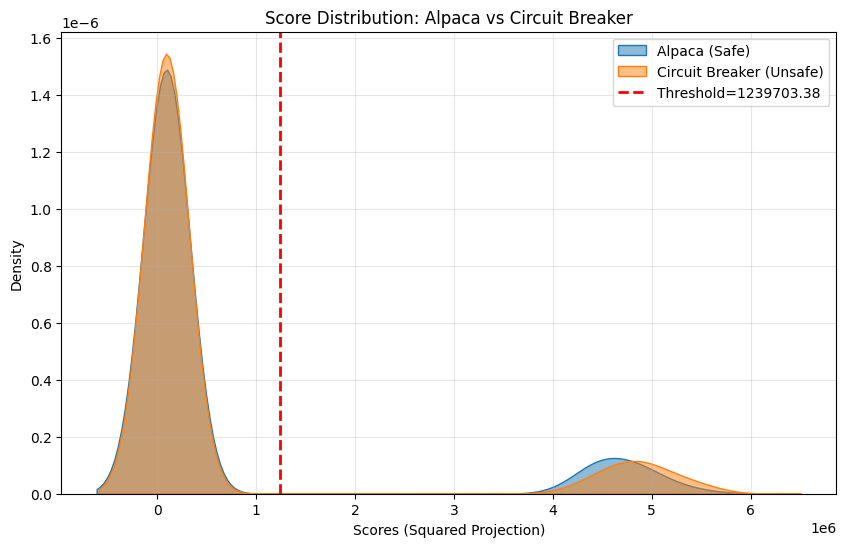

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
alpaca_reps = np.load('../data/tool_dataset/beavertails/reps/llama2-7b-chat-hf/30k/layers/layer_-15/benign.npy')
cb_reps = np.load('../data/tool_dataset/beavertails/reps/llama2-7b-chat-hf/30k/layers/layer_-15/harmful.npy')
representations = np.vstack([alpaca_reps, cb_reps])
y_test2 = np.concatenate([
    np.zeros(len(alpaca_reps)),
    np.ones(len(cb_reps))
])

# Preprocess
representations = representations - representations.mean(axis=0)
representations = representations.astype(np.float32)

# SVD and score calculation
U, sigma, VT = np.linalg.svd(representations)
VT1 = VT[0]
scores_projection = np.dot(representations, VT1)
scores = scores_projection ** 2

# Calculate threshold
threshold = scores.min() + (20 * (scores.max() - scores.min())) / 100

# Create density plot
plt.figure(figsize=(10, 6))
for label in [0, 1]:
    subset = scores[y_test2 == label]
    label_name = 'Alpaca (Safe)' if label == 0 else 'Circuit Breaker (Unsafe)'
    sns.kdeplot(subset, alpha=0.5, fill=True, label=label_name)

plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold={threshold:.2f}')
plt.xlabel('Scores (Squared Projection)')
plt.ylabel('Density')
plt.title('Score Distribution: Alpaca vs Circuit Breaker')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

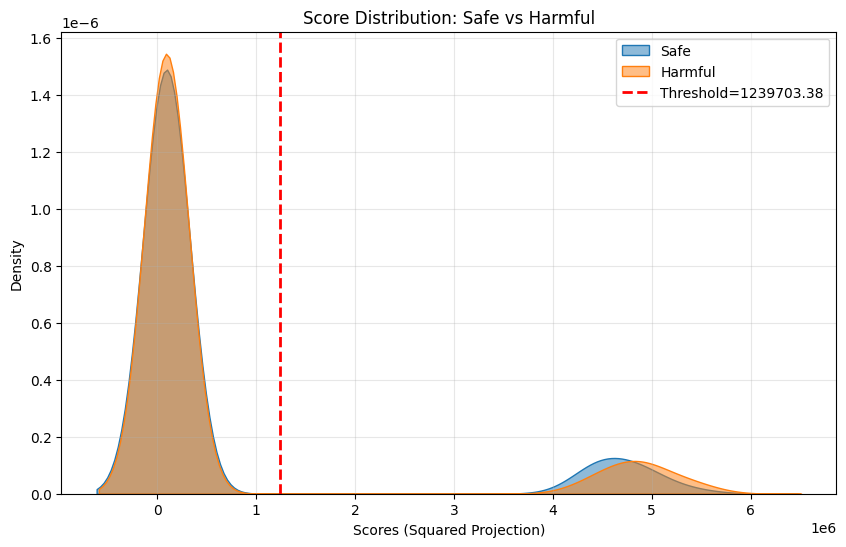

In [4]:
plt.figure(figsize=(10, 6))
for label in [0, 1]:
    subset = scores[y_test2 == label]
    label_name = 'Safe' if label == 0 else 'Harmful'
    sns.kdeplot(subset, alpha=0.5, fill=True, label=label_name)

plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold={threshold:.2f}')
plt.xlabel('Scores (Squared Projection)')
plt.ylabel('Density')
plt.title('Score Distribution: Safe vs Harmful')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Best number of components: 4
Best AUC: 0.8521


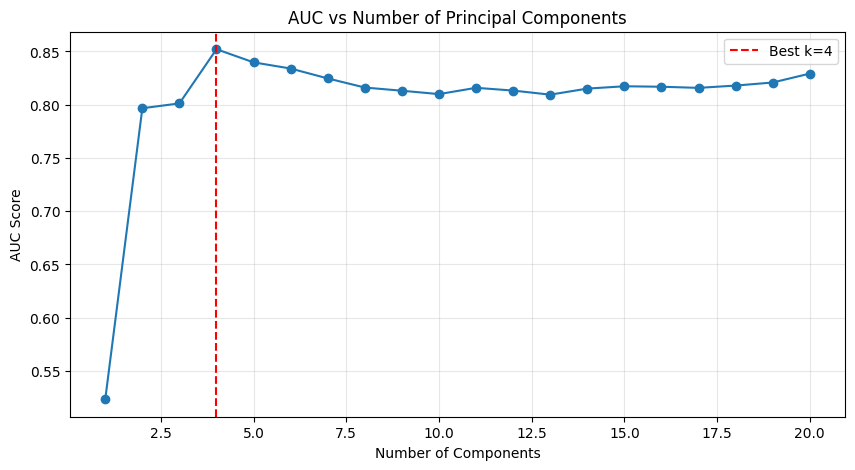

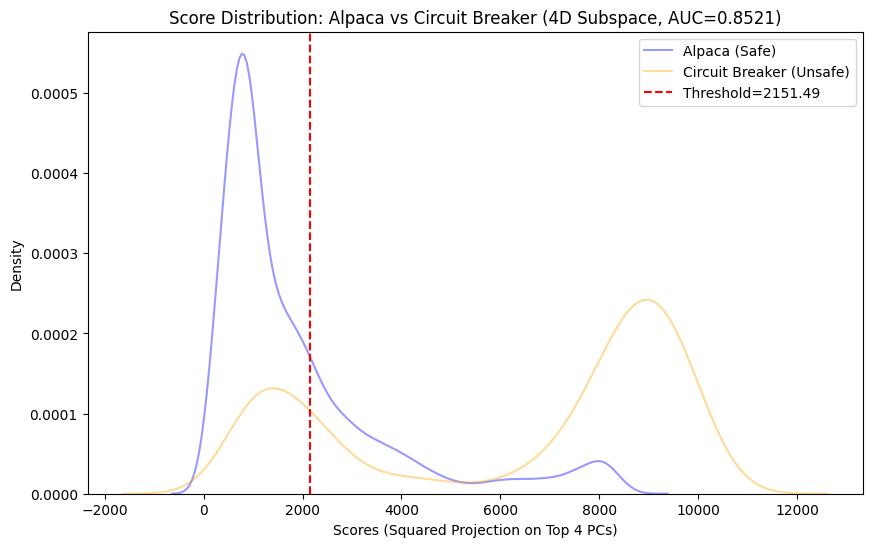

In [15]:
# Try different numbers of components and select the best
max_components = min(20, VT.shape[0])  # Test up to 20 components
best_auc = 0
best_k = 1
auc_scores = []

for k in range(1, max_components + 1):
    VT_topk = VT[:k]
    projections = np.dot(representations, VT_topk.T)
    scores = np.sum(projections ** 2, axis=1)
    
    # Calculate AUC (higher is better separation)
    auc = roc_auc_score(y_test2, scores)
    # Since we don't know which direction is "harmful", take max(auc, 1-auc)
    auc = max(auc, 1 - auc)
    auc_scores.append(auc)
    
    if auc > best_auc:
        best_auc = auc
        best_k = k

print(f"Best number of components: {best_k}")
print(f"Best AUC: {best_auc:.4f}")

# Plot AUC vs number of components
plt.figure(figsize=(10, 5))
plt.plot(range(1, max_components + 1), auc_scores, marker='o')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('Number of Components')
plt.ylabel('AUC Score')
plt.title('AUC vs Number of Principal Components')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Use the best k for final visualization
VT_best = VT[:best_k]
projections = np.dot(representations, VT_best.T)
scores = np.sum(projections ** 2, axis=1)

alpaca_scores = scores[y_test2 == 0]
cb_scores = scores[y_test2 == 1]

threshold = scores.min() + (20 * (scores.max() - scores.min())) / 100

# Plot final distribution
plt.figure(figsize=(10, 6))
sns.kdeplot(alpaca_scores, color="blue", alpha=0.4, label="Alpaca (Safe)")
sns.kdeplot(cb_scores, color="orange", alpha=0.4, label="Circuit Breaker (Unsafe)")
plt.axvline(x=threshold, color="red", linestyle="--", label=f"Threshold={threshold:.2f}")
plt.xlabel(f"Scores (Squared Projection on Top {best_k} PCs)")
plt.ylabel("Density")
plt.title(f"Score Distribution: Alpaca vs Circuit Breaker ({best_k}D Subspace, AUC={best_auc:.4f})")
plt.legend()
plt.show()


AUC: 0.8521

Optimal threshold: 6356.95
TPR: 0.640, FPR: 0.061

Confusion Matrix:
                    Pred Harmful (1)  Pred Safe (0)
Actual Harmful (1)              3195           1799
Actual Safe (0)                 3156          48846

Classification Report:
              precision    recall  f1-score   support

        Safe       0.96      0.94      0.95     52002
     Harmful       0.50      0.64      0.56      4994

    accuracy                           0.91     56996
   macro avg       0.73      0.79      0.76     56996
weighted avg       0.92      0.91      0.92     56996



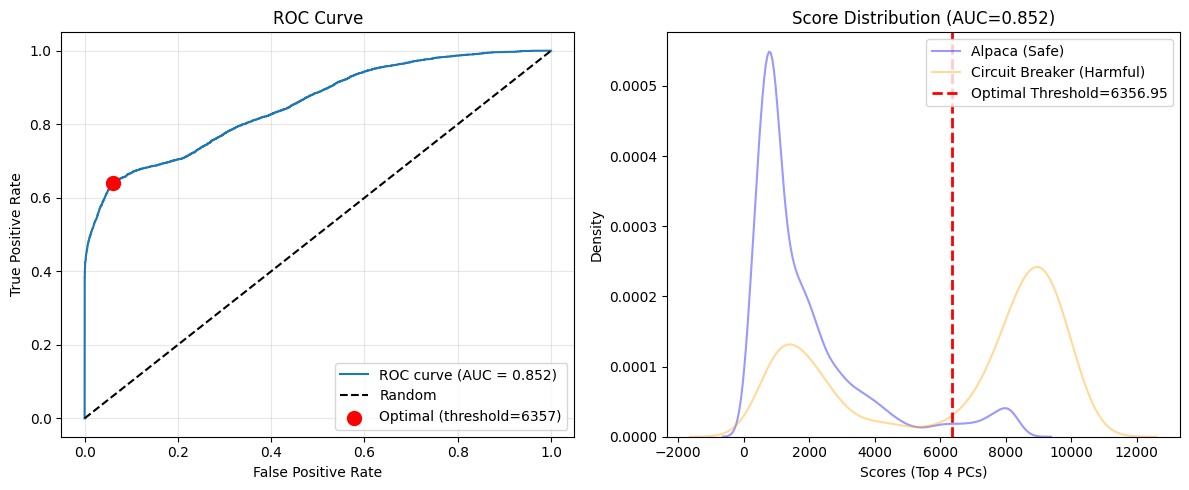

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

# Use top k components
k = 4
VT_topk = VT[:k]
projections = np.dot(representations, VT_topk.T)
scores = np.sum(projections ** 2, axis=1)

# Calculate AUC
auc = roc_auc_score(y_test2, scores)
auc = max(auc, 1 - auc)
print(f"AUC: {auc:.4f}")

# Find optimal threshold using Youden's J
fpr, tpr, thresholds = roc_curve(y_test2, scores)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"\nOptimal threshold: {optimal_threshold:.2f}")
print(f"TPR: {tpr[optimal_idx]:.3f}, FPR: {fpr[optimal_idx]:.3f}")

# Make predictions with optimal threshold
pred_is_harmful = scores > optimal_threshold

# Evaluate
print("\nConfusion Matrix:")
tn, fp, fn, tp = confusion_matrix(y_test2, pred_is_harmful).ravel()
cm = pd.DataFrame(
    [[tp, fn],
     [fp, tn]],
    index=["Actual Harmful (1)", "Actual Safe (0)"],
    columns=["Pred Harmful (1)", "Pred Safe (0)"]
)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test2, pred_is_harmful, 
                          target_names=['Safe', 'Harmful']))

# Visualize with optimal threshold
alpaca_scores = scores[y_test2 == 0]
cb_scores = scores[y_test2 == 1]

plt.figure(figsize=(12, 5))

# ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], c='red', s=100, 
           label=f'Optimal (threshold={optimal_threshold:.0f})', zorder=5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)

# Density plot
plt.subplot(1, 2, 2)
sns.kdeplot(alpaca_scores, color="blue", alpha=0.4, label="Alpaca (Safe)")
sns.kdeplot(cb_scores, color="orange", alpha=0.4, label="Circuit Breaker (Harmful)")
plt.axvline(x=optimal_threshold, color="red", linestyle="--", linewidth=2,
           label=f"Optimal Threshold={optimal_threshold:.2f}")
plt.xlabel(f"Scores (Top {k} PCs)")
plt.ylabel("Density")
plt.title(f"Score Distribution (AUC={auc:.3f})")
plt.legend()

plt.tight_layout()
plt.show()